<a href="https://colab.research.google.com/github/pamamezcua60-coder/Proyectos_Fine_Tuning/blob/dev/Predicciones_precios.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Predección de precios con modelo finetuneado vs modelo Base

In [1]:
#instalaciones
!pip install -q datasets==2.21.0
!pip install -q transformers==4.43.1 trl==0.9.6 peft==0.12.0 accelerate==0.32.1
!pip install -q --upgrade bitsandbytes
!pip install -q triton==3.1.0
!pip install numpy==1.26.4 --force-reinstall


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 12.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.4/9.4 MB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 245.8/245.8 kB 7.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.4/296.4 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 314.1/314.1 kB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━

In [1]:
# imports

import os
import re
import math
from tqdm import tqdm
from google.colab import userdata
from huggingface_hub import login
import torch
import torch.nn.functional as F
import transformers
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, set_seed
from datasets import load_dataset, Dataset, DatasetDict
from datetime import datetime
from peft import PeftModel, LoraConfig
import matplotlib.pyplot as plt

In [2]:
# Datos del proyecto, data y usuario de HF
BASE_MODEL = "meta-llama/Meta-Llama-3.1-8B"
PROJECT_NAME = "pricer"
HF_USER = "PamAmezcua"
RUN_NAME = "2026-06-11_13.31.28"
PROJECT_RUN_NAME = f"{PROJECT_NAME}-{RUN_NAME}"
REVISION = "34734cf60ae758dbfacc5924f7d24e98ed72a06e" # or REVISION = None (para acceder a la última revisión), especifica el commit que deseamos usar. Segun se vaya so reajustando podríamos irnos a un commit anterior, no al último.
FINETUNED_MODEL = f"{HF_USER}/{PROJECT_RUN_NAME}"
DATASET_NAME = f"{HF_USER}/lite-data"

# Hiperparámetros de cuantización del modelo base.
QUANT_4_BIT = True

%matplotlib inline

# Colores usados para marcar en la gráfica aquellas predicciones que hacen "Hit".
GREEN = "\033[92m"
YELLOW = "\033[93m"
RED = "\033[91m"
RESET = "\033[0m"
COLOR_MAP = {"red":RED, "orange": YELLOW, "green": GREEN}

In [3]:
# Log in en HuggingFace
hf_token = userdata.get('HF_TOKEN')
login(hf_token, add_to_git_credential=True)

In [4]:
#Descarga de conjunto de train y test de Hugging Face, en este código el conjunto de train no se usa
dataset = load_dataset(DATASET_NAME)
train = dataset['train']
test = dataset['test']

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [5]:
#Ejemplo
test[0]

{'text': "¿Cuánto cuesta esto redondeado al dólar más cercano?\n\nSetpower Insulated Protective Cover for AJ30 Portable Refrigerator Freezer, suitable for AJ30 Only\nInsulation & Waterproof well-made insulation could save battery power and improve cooling efficiency by preventing cold air from flowing away. Durable and Foldable with its oxford cloth outer layer, it's durable and protects your portable refrigerator from scratches and dust. Expanded Bag for Accessories two expanded bags on its side, expand space to store the other accessories. Great Ventilation a hollowed design for positions of vents doesn't affect the ventilation. Attention this insulated cover is ONLY suitable for SetPower AJ30 portable refrigerator. FIT TO AJ30 ONLY. Brand Name Setpower, Model Info AJ30 COVER, model number AJ30 COVER, Installation Type Freestanding, Part AJ30 cover, Special Features Portable, Color\n\nPrice is $",
 'price': 65.99}

In [6]:
len(train), len(test)

(25000, 2000)

# Funciones adicionales: extracción/predicción de precio y métricas de testeo

In [7]:
#Función de extracción de precio de un item del conjunto
def extract_price(s):
    if "Price is $" in s:
      contents = s.split("Price is $")[1]
      contents = contents.replace(',','')
      match = re.search(r"[-+]?\d*\.\d+|\d+", contents)
      return float(match.group()) if match else 0
    return 0

In [8]:
#Ejemplo
extract_price("Price is $99.99")

99.99

In [9]:
#Función de prediccion de precio con finetuned_model_predict
def finetuned_model_predict(prompt):
    set_seed(42)
    inputs = tokenizer.encode(prompt, return_tensors="pt").to("cuda") #codificar a tokens numericos y mandar a cuda
    attention_mask = torch.ones(inputs.shape, device="cuda") #pequeña linea para evitarnos una advertencia
    outputs = fine_tuned_model.generate(inputs, attention_mask=attention_mask, max_new_tokens=3, num_return_sequences=1) #se le pasa el input codificado, genera maximo de 3 tokens de salida, pero con uno basta (el precio mismo)
    response = tokenizer.decode(outputs[0])#tokenizer decodifica par leerlo en letras.
    return extract_price(response) #de nuestra respuesta se extrae el precio

In [10]:
#Función de prediccion de precio con base_model
def base_model_predict(prompt):
    set_seed(42)
    inputs = tokenizer.encode(prompt, return_tensors="pt").to("cuda") #codificar a tokens numericos y mandar a cuda
    attention_mask = torch.ones(inputs.shape, device="cuda") #pequeña linea para evitarnos una advertencia
    outputs = base_model.generate(inputs, attention_mask=attention_mask, max_new_tokens=3, num_return_sequences=1) #se le pasa el input codificado, genera maximo de 3 tokens de salida, pero con uno basta (el precio mismo)
    response = tokenizer.decode(outputs[0])#tokenizer decodifica par leerlo en letras.
    return extract_price(response) #de nuestra respuesta se extrae el precio

In [11]:
class Tester:

    def __init__(self, predictor, data, title=None, size=250):
        self.predictor = predictor
        self.data = data
        self.title = title or predictor.__name__.replace("_", " ").title()
        self.size = size
        self.guesses = []
        self.truths = []
        self.errors = []
        self.sles = []
        self.colors = []

    def color_for(self, error, truth):
        if  error/truth < 0.2: #error<40 or
            return "green"
        elif error/truth < 0.4: #error<80 or
            return "orange"
        else:
            return "red"

    def run_datapoint(self, i):
        datapoint = self.data[i]
        guess = self.predictor(datapoint["text"])
        truth = datapoint["price"]
        error = abs(guess - truth)
        log_error = math.log(truth+1) - math.log(guess+1)
        sle = log_error ** 2
        color = self.color_for(error, truth)
        title = datapoint["text"].split("\n\n")[1][:20] + "..."
        self.guesses.append(guess)
        self.truths.append(truth)
        self.errors.append(error)
        self.sles.append(sle)
        self.colors.append(color)
        print(f"{COLOR_MAP[color]}{i+1}: Guess: ${guess:,.2f} Truth: ${truth:,.2f} Error: ${error:,.2f} SLE: {sle:,.2f} Item: {title}{RESET}")

    def chart(self, title):
        max_error = max(self.errors)
        plt.figure(figsize=(12, 8))
        max_val = max(max(self.truths), max(self.guesses))
        plt.plot([0, max_val], [0, max_val], color='deepskyblue', lw=2, alpha=0.6)
        plt.scatter(self.truths, self.guesses, s=3, c=self.colors)
        plt.xlabel('Valor Real')
        plt.ylabel('Estimación del Modelo')
        plt.xlim(0, max_val)
        plt.ylim(0, max_val)
        plt.title(title)
        plt.show()

    def report(self):
        average_error = sum(self.errors) / self.size
        rmsle = math.sqrt(sum(self.sles) / self.size)
        hits = sum(1 for color in self.colors if color=="green")
        title = f"{self.title}. Mean error=${average_error:,.2f}. Hits={hits/self.size*100:.1f}%"
        self.chart(title)

    def run(self):
        self.error = 0
        for i in range(self.size):
            self.run_datapoint(i)
        self.report()

    @classmethod
    def test(cls, function, data):
        cls(function, data).run()

# Modelo Base

#### Cuantización

In [12]:
if QUANT_4_BIT:
  quant_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_quant_type="nf4"
  )
else:
  bnb_config = BitsAndBytesConfig(
    load_in_8bit=True,
    bnb_8bit_compute_dtype=torch.bfloat16
  )

#### Llamada al tokenizador y modelo base

In [13]:
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    quantization_config=quant_config,
    device_map="auto",
)
base_model.generation_config.pad_token_id = tokenizer.pad_token_id


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/73.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/826 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

...

model-00003-of-00004.safetensors:   0%|          | 0.00/4.92G [00:00<?, ?B/s]

model-00004-of-00004.safetensors:   0%|          | 0.00/1.17G [00:00<?, ?B/s]

Loading checkpoint shards:   0%|          | 0/4 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

In [14]:
#arquitectura del modelo base
base_model

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 4096)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaSdpaAttention(
          (q_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (k_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (v_proj): Linear4bit(in_features=4096, out_features=1024, bias=False)
          (o_proj): Linear4bit(in_features=4096, out_features=4096, bias=False)
          (rotary_emb): LlamaRotaryEmbedding()
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (up_proj): Linear4bit(in_features=4096, out_features=14336, bias=False)
          (down_proj): Linear4bit(in_features=14336, out_features=4096, bias=False)
          (act_fn): SiLU()
        )
        (input_layernorm): LlamaRMSNorm()
        (post_attention_layernorm): LlamaRMSNorm()
      )
    )
    (norm): Ll

#### Pruebas sobre 250 elementos del conjunto de test

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


1: Guess: $25.99 Truth: $65.99 Error: $40.00 SLE: 0.83 Item: Setpower Insulated P...
2: Guess: $1.00 Truth: $9.68 Error: $8.68 SLE: 2.81 Item: TUAIC Refrigerator D...
3: Guess: $89.99 Truth: $155.98 Error: $65.99 SLE: 0.30 Item: Kegco Secondary Regu...
4: Guess: $7.99 Truth: $5.59 Error: $2.40 SLE: 0.10 Item: Refrigerator Door Sp...
5: Guess: $7.00 Truth: $98.40 Error: $91.40 SLE: 6.35 Item: Ice-O-Matic Float Va...
6: Guess: $19.95 Truth: $54.99 Error: $35.04 SLE: 0.97 Item: Wireless Temperature...
7: Guess: $7.99 Truth: $5.71 Error: $2.28 SLE: 0.09 Item: 3Inch Thermometer Hy...
8: Guess: $7.00 Truth: $9.53 Error: $2.53 SLE: 0.08 Item: GE GE Timer Knob Ass...
9: Guess: $7.99 Truth: $11.24 Error: $3.25 SLE: 0.10 Item: newlifeapp Dryer Lin...
10: Guess: $25.00 Truth: $12.88 Error: $12.12 SLE: 0.39 Item: Away NV350 NV351 NV3...
11: Guess: $25.00 Truth: $99.99 Error: $74.99 SLE: 1.84 Item: Refrigerator Ice Mak...
12: Guess: $19.99 Truth: $16.99 Error: $3.00 SLE: 0.02 Item: 2 PACKS Water Fi

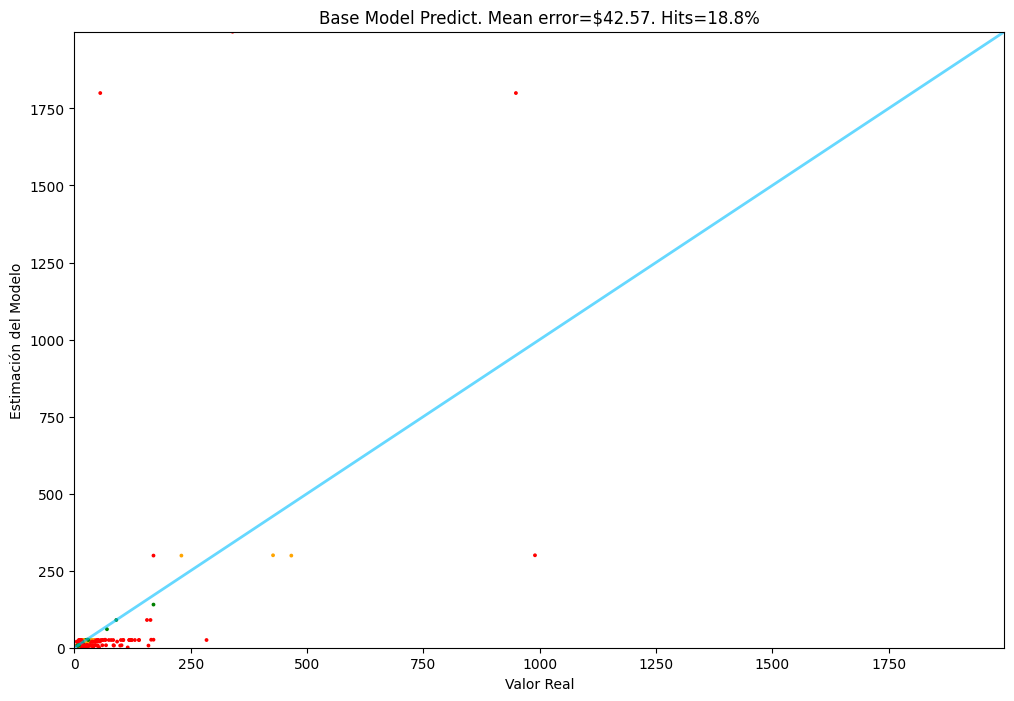

In [15]:
Tester.test(base_model_predict, test)

# Modelo Finetuneado

#### Ajuste con PEFT

In [16]:
if REVISION:
  fine_tuned_model = PeftModel.from_pretrained(base_model, FINETUNED_MODEL, revision=REVISION) #se coloca modelo base y modelo finetuneado y en revisión colocamos el commit que vamos a usar del finetuneado, en este caso el último
else:
  fine_tuned_model = PeftModel.from_pretrained(base_model, FINETUNED_MODEL)


print(f"Impacto en la memoria: {fine_tuned_model.get_memory_footprint() / 1e6:.1f} MB")

adapter_config.json:   0%|          | 0.00/681 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/109M [00:00<?, ?B/s]

Impacto en la memoria: 5700.6 MB


In [17]:
# Arquitectura del modelo
fine_tuned_model

PeftModelForCausalLM(
  (base_model): LoraModel(
    (model): LlamaForCausalLM(
      (model): LlamaModel(
        (embed_tokens): Embedding(128256, 4096)
        (layers): ModuleList(
          (0-31): 32 x LlamaDecoderLayer(
            (self_attn): LlamaSdpaAttention(
              (q_proj): lora.Linear4bit(
                (base_layer): Linear4bit(in_features=4096, out_features=4096, bias=False)
                (lora_dropout): ModuleDict(
                  (default): Dropout(p=0.1, inplace=False)
                )
                (lora_A): ModuleDict(
                  (default): Linear(in_features=4096, out_features=32, bias=False)
                )
                (lora_B): ModuleDict(
                  (default): Linear(in_features=32, out_features=4096, bias=False)
                )
                (lora_embedding_A): ParameterDict()
                (lora_embedding_B): ParameterDict()
                (lora_magnitude_vector): ModuleDict()
              )
              (k_proj): 

#### Prueba sobre 250 elementos del conjunto de test

1: Guess: $40.00 Truth: $65.99 Error: $25.99 SLE: 0.24 Item: Setpower Insulated P...
2: Guess: $10.00 Truth: $9.68 Error: $0.32 SLE: 0.00 Item: TUAIC Refrigerator D...
3: Guess: $110.00 Truth: $155.98 Error: $45.98 SLE: 0.12 Item: Kegco Secondary Regu...
4: Guess: $12.00 Truth: $5.59 Error: $6.41 SLE: 0.46 Item: Refrigerator Door Sp...
5: Guess: $54.00 Truth: $98.40 Error: $44.40 SLE: 0.35 Item: Ice-O-Matic Float Va...
6: Guess: $25.00 Truth: $54.99 Error: $29.99 SLE: 0.59 Item: Wireless Temperature...
7: Guess: $7.00 Truth: $5.71 Error: $1.29 SLE: 0.03 Item: 3Inch Thermometer Hy...
8: Guess: $12.00 Truth: $9.53 Error: $2.47 SLE: 0.04 Item: GE GE Timer Knob Ass...
9: Guess: $25.00 Truth: $11.24 Error: $13.76 SLE: 0.57 Item: newlifeapp Dryer Lin...
10: Guess: $20.00 Truth: $12.88 Error: $7.12 SLE: 0.17 Item: Away NV350 NV351 NV3...
11: Guess: $93.00 Truth: $99.99 Error: $6.99 SLE: 0.01 Item: Refrigerator Ice Mak...
12: Guess: $20.00 Truth: $16.99 Error: $3.01 SLE: 0.02 Item: 2 PACKS Wat

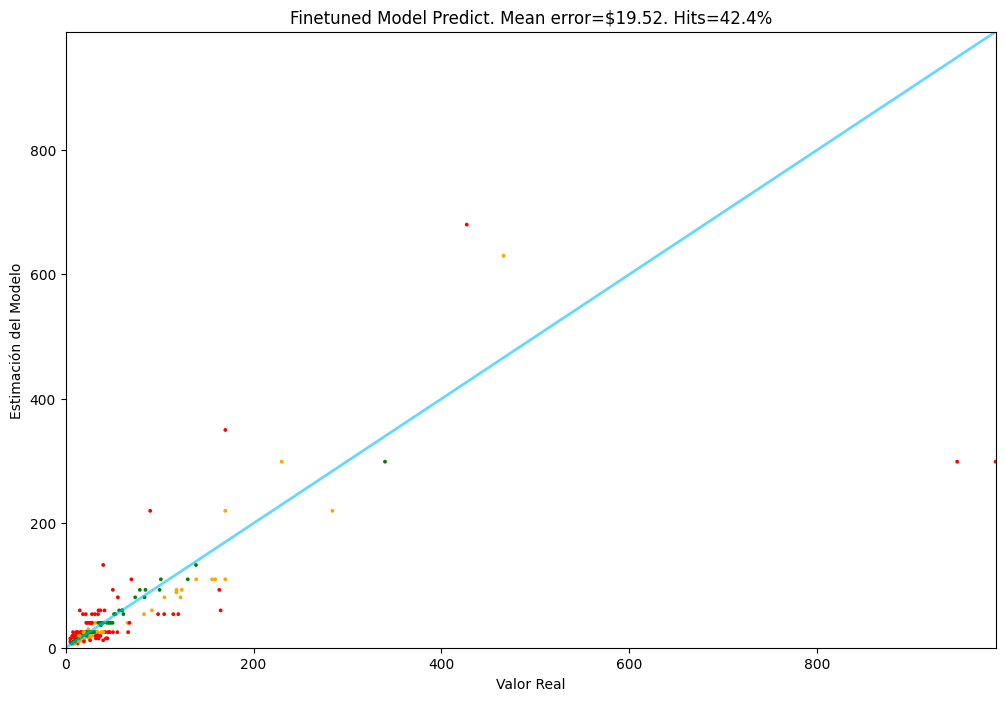

In [18]:
Tester.test(finetuned_model_predict, test)

#### Predicción y prueba alterna:
Esta predicción propone que se consideren los tres tokens con mayor probabilidad y se promedien considerando sus pesos (la probabilidad de cada uno de ellos).

In [19]:
# Una función de predicción mejorada toma un promedio ponderado de las 3 opciones principales
# Este código sería más complejo si no pudiéramos aprovechar el hecho de que Llama genera 1 token para cualquier número de 3 dígitos

top_K = 3 #toma los siguientes 3 tokens más probables

def improved_model_predict(prompt, device="cuda"):
    set_seed(42)
    inputs = tokenizer.encode(prompt, return_tensors="pt").to(device)
    attention_mask = torch.ones(inputs.shape, device=device)

    with torch.no_grad():
        outputs = fine_tuned_model(inputs, attention_mask=attention_mask)
        next_token_logits = outputs.logits[:, -1, :].to('cpu') #funcion para obtener la lista de logits

    next_token_probs = F.softmax(next_token_logits, dim=-1)#funcion para acceder a la funcion softmax
    top_prob, top_token_id = next_token_probs.topk(top_K) #función para quedarse con los tres tokens de mayor probabilidad
    prices, weights = [], []
    for i in range(top_K): #Para ver los top k tokens
      predicted_token = tokenizer.decode(top_token_id[0][i])
      probability = top_prob[0][i]
      try:
        result = float(predicted_token)
      except ValueError as e:
        result = 0.0
      if result > 0:
        prices.append(result)
        weights.append(probability)
    if not prices:
      return 0.0, 0.0
    total = sum(weights)
    weighted_prices = [price * weight / total for price, weight in zip(prices, weights)] #la nueva predicción se obtiene como el promedio de las tres predicciones más probables, pero con la afectación del peso en cada predicción.
    return sum(weighted_prices).item()

We detected that you are passing `past_key_values` as a tuple and this is deprecated and will be removed in v4.43. Please use an appropriate `Cache` class (https://huggingface.co/docs/transformers/v4.41.3/en/internal/generation_utils#transformers.Cache)


1: Guess: $35.74 Truth: $65.99 Error: $30.25 SLE: 0.36 Item: Setpower Insulated P...
2: Guess: $9.35 Truth: $9.68 Error: $0.33 SLE: 0.00 Item: TUAIC Refrigerator D...
3: Guess: $126.31 Truth: $155.98 Error: $29.67 SLE: 0.04 Item: Kegco Secondary Regu...
4: Guess: $12.86 Truth: $5.59 Error: $7.27 SLE: 0.55 Item: Refrigerator Door Sp...
5: Guess: $53.10 Truth: $98.40 Error: $45.30 SLE: 0.37 Item: Ice-O-Matic Float Va...
6: Guess: $33.94 Truth: $54.99 Error: $21.05 SLE: 0.22 Item: Wireless Temperature...
7: Guess: $7.14 Truth: $5.71 Error: $1.43 SLE: 0.04 Item: 3Inch Thermometer Hy...
8: Guess: $11.11 Truth: $9.53 Error: $1.58 SLE: 0.02 Item: GE GE Timer Knob Ass...
9: Guess: $18.85 Truth: $11.24 Error: $7.61 SLE: 0.23 Item: newlifeapp Dryer Lin...
10: Guess: $18.75 Truth: $12.88 Error: $5.87 SLE: 0.12 Item: Away NV350 NV351 NV3...
11: Guess: $94.75 Truth: $99.99 Error: $5.24 SLE: 0.00 Item: Refrigerator Ice Mak...
12: Guess: $20.00 Truth: $16.99 Error: $3.01 SLE: 0.02 Item: 2 PACKS Water

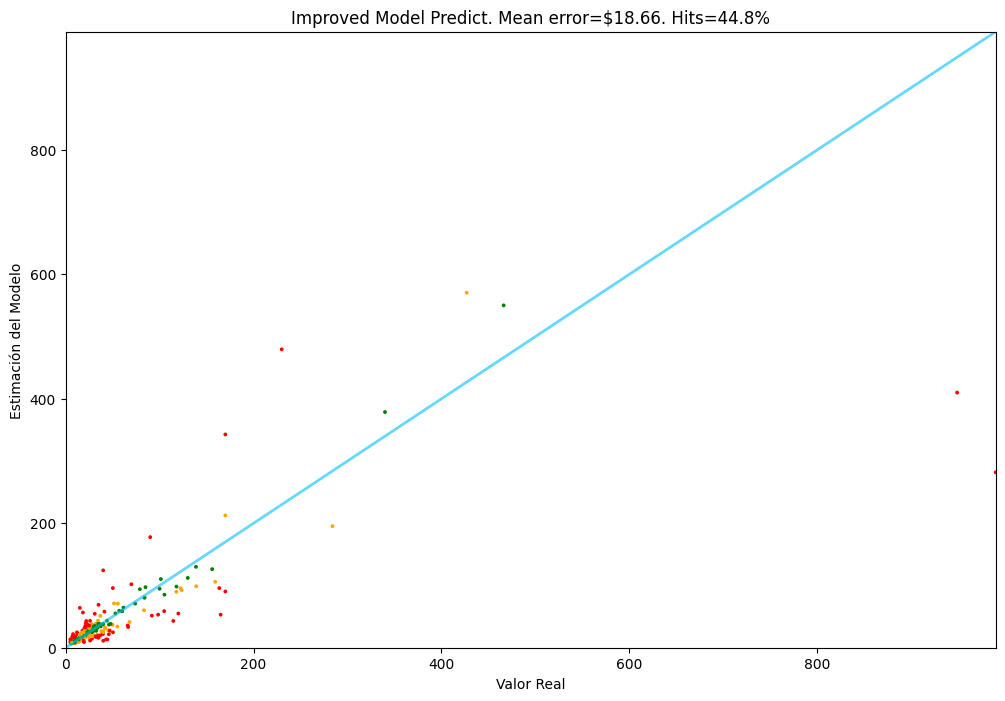

In [20]:
Tester.test(improved_model_predict, test)